## TensorFlow and Deep Learning Basics

In [5]:
import tensorflow as tf
from tensorflow import keras

In [6]:
physical_devices = tf.config.experimental.list_physical_devices('GPU')
print("GPUs Available: ", len(physical_devices))

GPUs Available:  1


# Import Essential Libraries

In [8]:
from keras.models import Sequential
from keras.layers import Dense, Activation 

## Steps to design a Network:

<li>Define the model using Sequential, Dense, and Activation Functions.</li>
<li>Activation functions can be Relu, Softmax, Sigmoid, Tanh, LeakyRelu, etc.</li>
<li>Activation functions introduce non-linearity to the network.</li>
<li>Sigmoid activation function mostly is used in the last layer for binary classiication. On the other hand, softmax is used when we have multiple output or multi-class classification.</li>
<li>Using model.summary, you can see the model and trainable parameters.</li>

In [77]:
model = Sequential([
                   Dense(4, input_shape = (1, ), activation = 'relu'),
                   Dense(3, activation = 'relu'),
                   Dense(2, activation = 'softmax'),
                   
])

In [78]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 4)                 8         
                                                                 
 dense_22 (Dense)            (None, 3)                 15        
                                                                 
 dense_23 (Dense)            (None, 2)                 8         
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


#### Another way to define the sequential model.

In [13]:
model2 = Sequential()

model2.add(Dense(4, input_shape = (1, ), activation = 'relu'))
model2.add(Dense(3, activation = 'relu'))
model2.add(Dense(2, activation = 'softmax'))

## How calculate the model parameters by hand#
In this example: (4 * 1) + (4 * 3) + (3 * 2) + (4+3+2) = 31 

In [14]:
model2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 4)                 8         
                                                                 
 dense_1 (Dense)             (None, 3)                 15        
                                                                 
 dense_2 (Dense)             (None, 2)                 8         
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


## The next step is compiling the model.

In [15]:
from keras.metrics import categorical_crossentropy

In [31]:
model.compile(tf.keras.optimizers.Adam(learning_rate = 0.0001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [17]:
model.optimizer.learning_rate

<tf.Variable 'learning_rate:0' shape=() dtype=float32, numpy=1e-04>

<h1>Create Our Own Random Datastet that We can Train Our Neural Network </h1>

<li>A vaccine is tested on 5250 individuals from age 10 to 90.</li>
<li>The individuals are split into two equal groups. first group is under 50 years and the second group is over 50 years.</li>
<li>95% of group 1 had no side-effects.</li>
<li>95% in group 2 had side effects.</li>

In [79]:
import numpy as np
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler #To normalize data. 
from random import randint

In [80]:
training_set = []
training_labels = []

for i in range(125):
    random_under50 = randint(10,50)
    training_set.append(random_under50)
    training_labels.append(1)
    
    random_over50 = randint(51,90)
    training_set.append(random_over50)
    training_labels.append(0)
    
for i in range(2500):
    random_under50 = randint(10,50)
    training_set.append(random_under50)
    training_labels.append(0)
    
    random_over50 = randint(51,90)
    training_set.append(random_over50)
    training_labels.append(1)

In [81]:
training_labels = np.array(training_labels)
training_set = np.array(training_set)
training_labels, training_set = shuffle(training_labels, training_set)

In [82]:
training_labels.shape

(5250,)

In [83]:
training_set.shape

(5250,)

In [84]:
print(training_set)

[36 42 12 ... 53 77 85]


In [85]:
scaler = MinMaxScaler(feature_range = (0, 1))
scaled_training_set = scaler.fit_transform(training_set.reshape(-1, 1))

In [86]:
print(scaled_training_set)

[[0.325 ]
 [0.4   ]
 [0.025 ]
 ...
 [0.5375]
 [0.8375]
 [0.9375]]


In [87]:
model = Sequential([
                   Dense(12, input_shape = (1, ), activation = 'relu'),
                   Dense(24, activation = 'relu'),
                    Dense(12, activation = 'relu'),
                   Dense(2, activation = 'softmax')
                   
])

In [88]:
model.compile(tf.keras.optimizers.Adam(learning_rate = 0.0001),
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [89]:
model.fit(x=scaled_training_set, 
           y=training_labels, 
           validation_split=0.1, #In each epoch the model will train on 10 batch instead of 1 which spead up the training process.
           batch_size=10, #Use 10 percent of data as validation data
           epochs=30, 
           shuffle=True, 
           verbose=2)

Epoch 1/30
473/473 - 2s - loss: 0.6616 - accuracy: 0.6990 - val_loss: 0.6223 - val_accuracy: 0.8057 - 2s/epoch - 4ms/step
Epoch 2/30
473/473 - 1s - loss: 0.5754 - accuracy: 0.8226 - val_loss: 0.5288 - val_accuracy: 0.8724 - 1s/epoch - 3ms/step
Epoch 3/30
473/473 - 1s - loss: 0.4662 - accuracy: 0.8878 - val_loss: 0.4319 - val_accuracy: 0.9067 - 1s/epoch - 3ms/step
Epoch 4/30
473/473 - 1s - loss: 0.3719 - accuracy: 0.9253 - val_loss: 0.3646 - val_accuracy: 0.9238 - 1s/epoch - 3ms/step
Epoch 5/30
473/473 - 1s - loss: 0.3094 - accuracy: 0.9403 - val_loss: 0.3335 - val_accuracy: 0.9333 - 1s/epoch - 3ms/step
Epoch 6/30
473/473 - 1s - loss: 0.2779 - accuracy: 0.9486 - val_loss: 0.3153 - val_accuracy: 0.9257 - 1s/epoch - 3ms/step
Epoch 7/30
473/473 - 1s - loss: 0.2608 - accuracy: 0.9484 - val_loss: 0.3106 - val_accuracy: 0.9333 - 1s/epoch - 3ms/step
Epoch 8/30
473/473 - 1s - loss: 0.2518 - accuracy: 0.9501 - val_loss: 0.3055 - val_accuracy: 0.9333 - 1s/epoch - 3ms/step
Epoch 9/30
473/473 - 1s 

### Generate a test set to validate the model

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

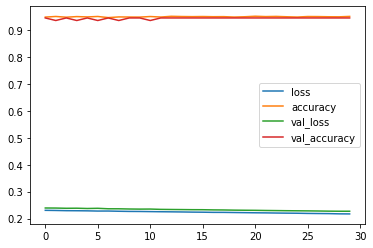

In [91]:
history = pd.DataFrame(model3.history.history)
history.plot()

In [92]:
test_set = []
test_labels = []

for i in range(25):
  random_under50 = randint(10, 50)
  test_set.append(random_under50)
  test_labels.append(1)

  random_over50 = randint(51, 90)
  test_set.append(random_over50)
  test_labels.append(0)


for i in range(500):
  random_under50 = randint(10, 50)
  test_set.append(random_under50)
  test_labels.append(0)

  random_over50 = randint(51, 90)
  test_set.append(random_over50)
  test_labels.append(1)

In [93]:
test_labels = np.array(test_labels)
test_set = np.array(test_set)
test_set, test_labels = shuffle(test_labels, test_set)
scaled_test_set = scaler.fit_transform(test_set.reshape(-1, 1))

In [94]:
scaled_test_set

array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [0.],
       [0.]])

## Model Prediction

In [95]:
predictions = model.predict(scaled_test_set, batch_size = 10, verbose = 0)

In [96]:
predictions

array([[0.9772968 , 0.02270312],
       [0.9772968 , 0.02270312],
       [0.9772968 , 0.02270312],
       ...,
       [0.01186318, 0.9881368 ],
       [0.9772968 , 0.02270312],
       [0.9772968 , 0.02270312]], dtype=float32)

In [102]:
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt

In [103]:
rounded_predictions = np.argmax(predictions, axis=-1)

In [104]:
rounded_predictions

array([0, 0, 0, ..., 1, 0, 0])

In [105]:
cm = confusion_matrix(y_true=test_labels, y_pred=rounded_predictions)

In [106]:
def plot_confusion_matrix(cm, classes, normalize=False, title="Confusion matrix", cmap=plt.cm.Blues):
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized Confusion Matrix")
  else:
    print("Confusion Matrix without Normalization")

  print(cm)

  thresh = cm.max() / 2.0

  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i,j], horizontalalignment="center", color="white" if cm[i,j] > thresh else "black")

  plt.tight_layout()
  plt.xlabel('Predicted label')
  plt.ylabel('True label')

Confusion Matrix without Normalization
[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 7  0  0 ...  0  0  0]
 ...
 [ 0 18  0 ...  0  0  0]
 [ 1  5  0 ...  0  0  0]
 [ 0 21  0 ...  0  0  0]]


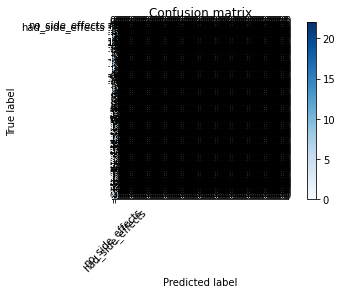

In [107]:
cm_plot_labels = ['no_side_effects', 'had_side_effects']
plot_confusion_matrix(cm=cm, classes=cm_plot_labels)

## How to save the Model?

In [108]:
import os.path
if os.path.isfile('medical_trial_model.h5') is False:
  model.save('medical_trial_model.h5')
  print("Model Saved!")

Model Saved!


In [109]:
from tensorflow.keras.models import load_model
new_model = load_model('medical_trial_model.h5')

In [110]:
new_model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 12)                24        
                                                                 
 dense_25 (Dense)            (None, 24)                312       
                                                                 
 dense_26 (Dense)            (None, 12)                300       
                                                                 
 dense_27 (Dense)            (None, 2)                 26        
                                                                 
Total params: 662
Trainable params: 662
Non-trainable params: 0
_________________________________________________________________


In [111]:
new_model.get_weights()

[array([[-0.04683917, -0.02389789, -0.3371105 , -0.0415417 ,  0.56564003,
          0.12997112, -0.39379913,  0.43083897, -0.2699161 , -0.44940704,
         -0.13115078,  0.58640814]], dtype=float32),
 array([ 0.16303582,  0.        ,  0.        ,  0.        , -0.05828495,
         0.1532145 ,  0.        , -0.10646053,  0.        ,  0.        ,
         0.        , -0.09397001], dtype=float32),
 array([[-1.90337077e-01, -6.44380152e-02,  4.49357778e-01,
         -3.03720325e-01,  2.53030714e-02, -2.01874480e-01,
          4.15854692e-01, -4.51696813e-02,  5.41782863e-02,
         -3.13333660e-01,  1.48085058e-01, -2.74171352e-01,
          3.19611281e-01,  1.18746124e-02,  3.66615355e-01,
          6.66213557e-02,  4.49078441e-01,  2.53722847e-01,
         -3.17012042e-01,  3.71677786e-01, -2.04275362e-02,
          2.11555228e-01,  1.46383673e-01,  7.33368024e-02],
        [ 2.48620570e-01,  3.60216498e-01, -1.99235260e-01,
         -1.92735195e-01, -3.14370930e-01, -8.06343853e-02,
 

In [112]:
new_model.optimizer